### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp


Parametro di forma stimato:  1.0444806707961805


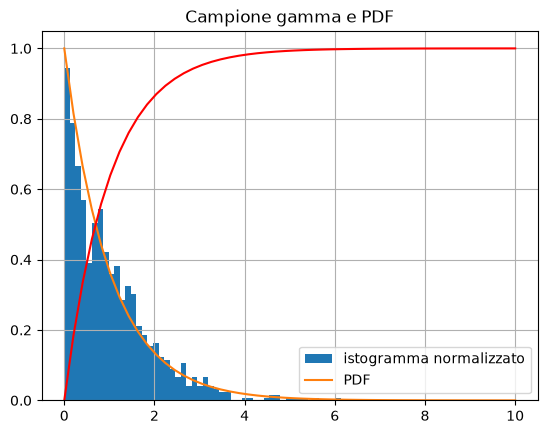

varianza:  1.0


In [2]:
# Valori casuali distribuzione gamme
dist = sp.stats.gamma(1)
sample = dist.rvs(size = 1000)

#istogramma del campione
x = np.linspace(0, 10)#creo i punti sull asse x

plt.hist(sample, bins=50, density=True, label='istogramma normalizzato')
plt.plot(x, dist.pdf(x), label='PDF')
plt.legend()
plt.title('Campione gamma e PDF')

#stima parametro del campione
a, loc, scale = sp.stats.gamma.fit(sample)
print('Parametro di forma stimato: ', a)

#CDF
plt.plot(x, dist.cdf(x), color='red', label = 'CDF')
plt.grid(True)
plt.show()

#varianza
print('varianza: ', dist.var())


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [3]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

mesi = np.arange(12)

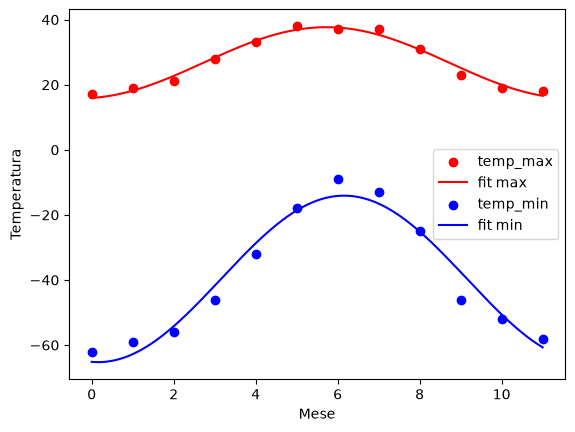

MAE_MAX: 1.0458509740625133 RMSE_MAX: 1.1946466156624642
MAE_MIN: 3.185078650542627 RMSE_MIN: 3.831099569192344


In [4]:
# Il periodo è noto e vale 12 mesi, quindi lo fisso invece di stimarlo:
# restano 3 parametri, a = ampiezza, b = valore medio, c = mese del massimo
def stagionale(x, a, b, c):
    return a * np.cos(2 * np.pi * (x - c) / 12) + b

p_max, _ = sp.optimize.curve_fit(stagionale, mesi, temp_max)
p_min, _ = sp.optimize.curve_fit(stagionale, mesi, temp_min)

# Griglia fitta per disegnare la curva continua senza spezzate
x = np.linspace(0, 11, 200)

plt.scatter(mesi, temp_max, color='red', label='temp_max')
plt.plot(x, stagionale(x, *p_max), color='red', label='fit max')
plt.scatter(mesi, temp_min, color='blue', label='temp_min')
plt.plot(x, stagionale(x, *p_min), color='blue', label='fit min')
plt.xlabel('Mese')
plt.ylabel('Temperatura')
plt.legend()
plt.show()


# Previsioni sui 12 mesi osservati: per le metriche servono queste, non la griglia fitta x
pred_max = stagionale(mesi, *p_max)
pred_min = stagionale(mesi, *p_min)

# MAE e RMSE, sono 2 perché ho 2 modelli
mae_max = np.mean(np.abs(temp_max - pred_max))
rmse_max = np.sqrt(np.mean((temp_max - pred_max) ** 2))

mae_min = np.mean(np.abs(temp_min - pred_min))
rmse_min = np.sqrt(np.mean((temp_min - pred_min) ** 2))

print('MAE_MAX:', mae_max, 'RMSE_MAX:', rmse_max)
print('MAE_MIN:', mae_min, 'RMSE_MIN:', rmse_min)

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [5]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


Coefficiente angolare : -0.04121511996278614
Intercetta: 29.59985475616395
R-quadro: 0.7183433404897298
P-value: 9.380326537381486e-10


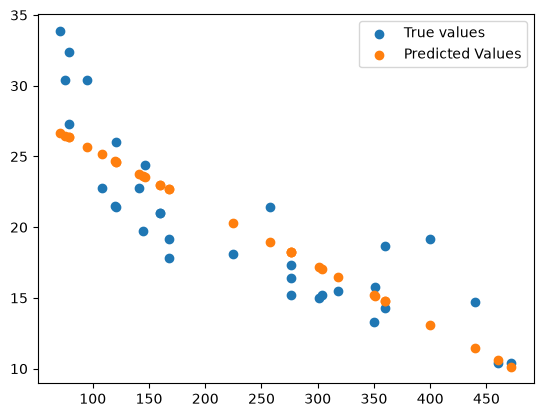

In [6]:
x = df['disp'].values
y = df['mpg'].values

slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
y_pred = slope * x + intercept

print(f'Coefficiente angolare : {slope}')
print(f'Intercetta: {intercept}')
print(f'R-quadro: {r_value**2}')
print(f'P-value: {p_value}')

plt.scatter(x,y, label = 'True values')
plt.scatter(x, y_pred, label = 'Predicted Values')
plt.legend()
plt.show()
